In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# <p style="background-color:#9c2162;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">TELCO CUSTOMER CHURN</p>

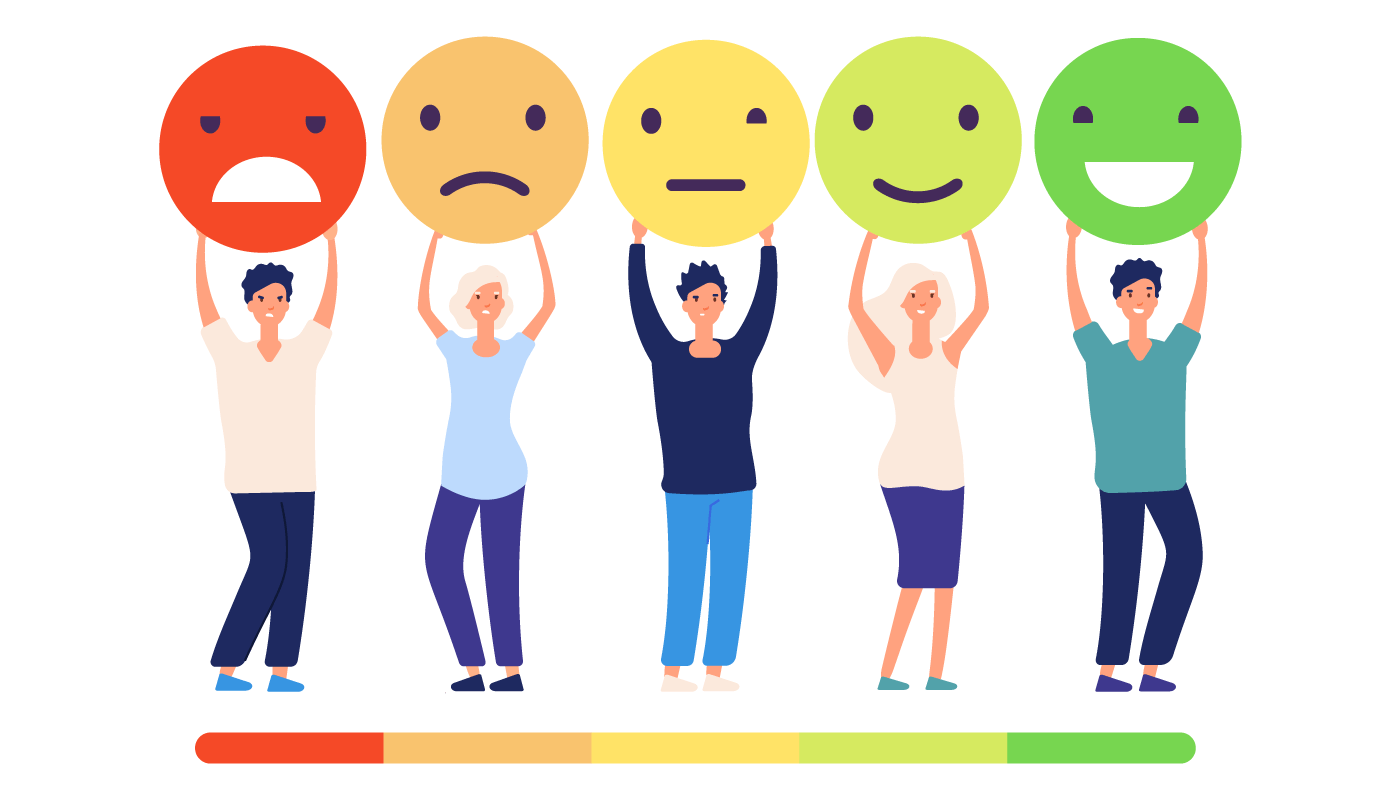

<p style="background-color:#9c2162;font-family:newtimeroman;color:#FFF9ED;font-size:140%;text-align:left;border-radius:10px 10px;">Image credit : https://technologyadvice.com/blog/sales/crm-stop-customer-churn/</p> 

<a id="toc"></a>

## <h3 style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;" class="list-group-item list-group-item-action active" data-toggle="list" role="tablist" aria-controls="home">TABLE OF CONTENTS</h3>

* [   PREFACE](#0)
* [1) LIBRARIES NEEDED IN THE STUDY](#1)
    * [1.1 User Defined Functions](#1.1)
* [2) DATA](#2)
    * [2.1 Context](#2.1)
    * [2.2 About the Features](#2.2) 
    * [2.3 What the Problem is](#2.3) 
* [3) ANALYSIS](#3)
    * [3.1) Reading the Data](#3)
* [4) EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION](#4)
    * [4.1 - A General Looking at the Data](#4.1)
    * [4.2 - Convert Multi-Index Columns To One Level](#4.2)
    * [4.3 - Handling with Missing Values](#4.3)
    * [4.4 The Examination of Target Variable](#4.4)
    * [4.5 - The Examination of Skewness, Kurtosis & Multicollinearity](#4.5)
    * [4.6 Numerical vs. Categorical](#4.6) 
        * [4.6.1 Spliting Dataset into Numeric & Categoric Features](#4.6.1)
        * [4.6.2 The Examination of Numerical Features](#4.6.2)
        * [4.6.3 The Examination of Categorical Features](#4.6.3)
    * [4.7 Descriptive Statistics](#4.7) 
* [5) DATA PREPROCESSING](#5)     
    * [5.1 The Implementation of Scaling](#5.1)
* [6) 6 - MODELLING WITH MULTIPLE ALGORITHMS](#6)        
    * [6.1 Modelling Default Parameters WITHOUT Scalling & class_weight](#6.1)
    * [6.2 Modelling Default Parameters WITH class_weight BUT Without Scalling](#6.2)
    * [6.3 Modelling Default Parameters WITH class_weight & Scaling](#6.3)
    * [6.4 Modelling Logistic Regression (class_weight AND Scaling) With GridSearchCV Best Parameters](#6.4)
* [7) THE VISUAL/TABULAR COMPARISON & EVALUATION OF MODELS](#7)
    * [7.1 Tabular Comparison of Model Scores](#7.1)
    * [7.2 Visual Comparison of Model Scores](#7.2)
* [8) CONLUSION](#8)
* [9) REFERENCES](#9)
* [10 FURTHER READINGS](#10)

<a id="0"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">PREFACE</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**Churn analysis is the evaluation of a company’s customer loss rate in order to reduce it. Also referred to as customer attrition rate, churn can be minimized by assessing your product and how people use it. In fact, acquiring new customers is considerably more expensive than maintaining and upgrading existing customer relationships. The more customers you churn, the more money you must spend to recoup the loss of business by finding new ones. Therefore, companies nowadays are more concerned than past and want to identify the causes of churn and implement effective strategies for retaining their customers.**

**In this Exploratory Data Analysis (EDA) and and a variety of Model Classifications including Logistic Regression (LR), Support Vector Machine (SVM), AdaBoosting (AB), GradientBoosting (GB), K-Nearest Neighbors (KNN), Random Forest (RF), Desicion Tree (DT), XGBoost (XGB), this study will examine the dataset named as "Telco Customer Churn" under the 'WA_Fn-UseC_-Telco-Customer-Churn.csv' file at Kaggle website [at Kaggle website](https://www.kaggle.com/blastchar/telco-customer-churn).**

**This study, in general, will cover what any beginner in Machine Learning can do as much as possible for a better understanding with the given dataset not only by examining its various aspects but also visualising it. Later Later S/he will be familiar with eight (8) Classification Algorithms in Machine Learning.**

<a id="1"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">1 - LIBRARIES NEEDED IN THE STUDY</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**First, if you do NOT have the following libraries in your kernel, just install them since you have to need them to import some libraries.**

In [ ]:
# !pip install pyforest
# !pip install ipython
# !pip install pyclustertend
# !pip install xlrd
# !pip install Autoviz
# !pip3 install termcolor
# !pip install termcolor
# !pip install pandas-profiling
# !pip install lightgbm
# !pip3 install catboost

In [ ]:
!pip install pyforest

**Let's begin importing libraries needed in the given analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
import pyforest
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, StandardScaler, PowerTransformer, MinMaxScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import RepeatedStratifiedKFold, KFold, cross_val_predict, train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Lasso, Ridge,ElasticNet
from sklearn.metrics import plot_confusion_matrix, r2_score, mean_absolute_error, mean_squared_error, classification_report, confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import make_scorer, precision_score, precision_recall_curve, plot_precision_recall_curve, plot_roc_curve, roc_auc_score, roc_curve, f1_score, accuracy_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostClassifier
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif, f_regression, mutual_info_regression
from xgboost import XGBRegressor, XGBClassifier
from xgboost import plot_importance
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#importing plotly and cufflinks in offline mode
import cufflinks as cf
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option('max_colwidth',200)

# pd.set_option('display.max_rows', 100) # if you wish to see more rows rather than default, just uncomment this line.
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

import colorama
from colorama import Fore, Style  # maakes strings colored
# !pip3 install termcolor
from termcolor import colored

# Import Pandas Profiling
import pandas_profiling

<a id="1.1"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">1.1 User Defined Functions</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**We have defined some useful user defined functions**

In [ ]:
###############################################################################

def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values

def missing_values(df):
    return missing(df)[missing(df)['Missing_Number']>0]

###############################################################################

def first_looking(df):
    print(colored("Shape:", attrs=['bold']), df.shape,'\n',
          f"There is ", df.shape[0], " observation and ", df.shape[1], " columns in the dataset.", '\n',
          colored('-'*79, 'red', attrs=['bold']),
          colored("\nInfo:\n", attrs=['bold']), sep='')
    print(df.info(), '\n', 
          colored('-'*79, 'red', attrs=['bold']), sep='')
    print(colored("Number of Uniques:\n", attrs=['bold']), df.nunique(),'\n',
          colored('-'*79, 'red', attrs=['bold']), sep='')
    print(colored("Missing Values:\n", attrs=['bold']), missing_values(df),'\n', 
          colored('-'*79, 'red', attrs=['bold']), sep='')
    print(colored("All Columns:", attrs=['bold']), list(df.columns),'\n', 
          colored('-'*79, 'red', attrs=['bold']), sep='')

    df.columns= df.columns.str.lower().str.replace('&', '_').str.replace(' ', '_')

    print(colored("Columns after rename:", attrs=['bold']), list(df.columns),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')

def duplicate_values(df):
    duplicate_values = df.duplicated(subset=None, keep='first').sum()
    if duplicate_values > 0:
        df.drop_duplicates(keep='first', inplace=True)
        print(duplicate_values, colored("duplicates were dropped", attrs=['bold']),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')
    else:
        print(colored("No duplicates", attrs=['bold']),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')
        
def drop_columns(df, drop_columns):
    if drop_columns !=[]:
        df.drop(drop_columns, axis=1, inplace=True)
        print(drop_columns, 'were dropped')
    else:
        print(colored('We will now check the missing values and if necessary drop some columns!!!', attrs=['bold']),'\n',
              colored('-'*79, 'red', attrs=['bold']), sep='')
        
def drop_null(df, limit):
    print('Shape:', df.shape)
    for i in df.isnull().sum().index:
        if (df.isnull().sum()[i]/df.shape[0]*100)>limit:
            print(df.isnull().sum()[i], 'percent of', i ,'null and were dropped')
            df.drop(i, axis=1, inplace=True)
            print('new shape:', df.shape)
        else:
            print(df.isnull().sum()[i], '%, percentage of missing values of', i ,'less than limit', limit, '%, so we will keep it.')
    print('New shape after missing value control:', df.shape)

###############################################################################

In [ ]:
# Function for determining the number and percentages of missing values

def missing (df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values

In [ ]:
# To view summary information about the column

def first_look(col):
    print("column name    : ", col)
    print("--------------------------------")
    print("per_of_nulls   : ", "%", round(df[col].isnull().sum()/df.shape[0]*100, 2))
    print("num_of_nulls   : ", df[col].isnull().sum())
    print("num_of_uniques : ", df[col].nunique())
    print(df[col].value_counts(dropna = False))

<a id="2"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">2 - DATA</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**This is the Telco customer churn data that contains information about a fictional telco company providing home phone and internet services to 7043 customers in California in Q3. It indicates which customers have left, stayed, or signed up for their service. Multiple important demographics are included for each customer, as well as a Satisfaction Score, Churn Score, and Customer Lifetime Value (CLTV) index.**

**For a better understanding and more information, please refer to [Cognos Analytics with Watson](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113) and [Kaggle Website](https://www.kaggle.com/blastchar/telco-customer-churn)**

<a id="2.1"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:left; border-radius:10px 10px;">2.1 Context</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]**

**Each row represents a customer, each column contains customer’s attributes described on the column Metadata.**

**The data set includes information about:**

- **Customers who left within the last month – the column is called Churn**
- **Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device -protection, tech support, and streaming TV and movies**
- **Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges**
- **Demographic info about customers – gender, age range, and if they have partners and dependents**

**To explore this type of models and learn more about the subject.**

**[New version](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113) from IBM.**

<a id="2.2"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:left; border-radius:10px 10px;">2.2 About The Features</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**The features in the given dataset are:**

- **CustomerID:** A unique ID that identifies each customer.

- **Gender:** The customer’s gender: Male, Female

- **Age:** The customer’s current age, in years, at the time the fiscal quarter ended.

- **Senior Citizen:** Indicates if the customer is 65 or older: Yes, No

- **Married (Partner):** Indicates if the customer is married: Yes, No

- **Dependents:** Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

- **Number of Dependents:** Indicates the number of dependents that live with the customer.

- **Phone Service:** Indicates if the customer subscribes to home phone service with the company: Yes, No

- **Multiple Lines:** Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

- **Internet Service:** Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

- **Online Security:** Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

- **Online Backup:** Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

- **Device Protection Plan:** Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

- **Premium Tech Support:** Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

- **Streaming TV:** Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

- **Streaming Movies:** Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

- **Contract:** Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

- **Paperless Billing:** Indicates if the customer has chosen paperless billing: Yes, No

- **Payment Method:** Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

- **Monthly Charge:** Indicates the customer’s current total monthly charge for all their services from the company.

- **Total Charges:** Indicates the customer’s total charges, calculated to the end of the quarter specified above.

- **Tenure:** Indicates the total amount of months that the customer has been with the company.

- **Churn:** Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

<a id="2.3"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:left; border-radius:10px 10px;">2.3 What The Problem Is</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**- In the given study, we have a classification problem.**

- We will try to create classifications on the target variable in the given dataset.
- The Target variable in the given dataset is "Churn"
- To make the best classification possible on the target variable, we will focus on if the target variable is balanced or not.
- As you will be familiar with later, the target variable in this study is an imblanced data so this researcher will concentrate Recall score on evaluating the results rather than Accuracy score used in the evaluation of balanced data.
- Lastly we will build a variety of Classification models and compare the models giving the best prediction on Churn.

<a id="3"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">3 - ANALYSIS</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

<a id="3.1"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">3.1 Reading The Data</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**How to read and assign the dataset as df, you can visit [pandas official Website](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) (You can define it as what you want instead of df)**

In [ ]:
df0 = pd.read_csv("../input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df0.copy()

In [ ]:
df.head()

<a id="4"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">4 - EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>


**Before performing Supervised Classification Algorithms, you need to know the data well in order to label the observations correctly. You need to analyze frequency distributions of features, relationships and correlations between the independent variables and the dependent variable. It is recommended to apply data visualization techniques. Observing breakpoints helps you to internalize the data.**

**So, in this Exploratory Data Analysis section the data will be analyzed by summarizing its main characteristics, using statistical graphics and other data visualization methods. As such the reader will be familiar with what the data can tell.**

**You can use first_looking(df) user defined function above for getting a general insight before going further in the analysis**

In [ ]:
first_looking(df)

<a id="4.1"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.1 A General Looking at the Data</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

Pandas profiling is an open source Python module with which we can quickly do an exploratory data analysis with just a few lines of code. Similarly, for EDA, profile_report() is One-Line Magical Code creating reports in the interactive HTML format which is quite easy to understand and analyze the data. In short, at the first hand, what pandas profiling does is to save us all the work of visualizing and understanding the distribution of each variable.

**For a better understanding and more information, please refer to [external link text](https://www.analyticsvidhya.com/blog/2021/06/generate-reports-using-pandas-profiling-deploy-using-streamlit/) & [external link text](https://towardsdatascience.com/exploratory-data-analysis-with-pandas-profiling-de3aae2ddff3)**

In [ ]:
df.profile_report()

In [ ]:
df.head(3)

In [ ]:
df.tail(3)

In [ ]:
df.sample(10)

In [ ]:
df.columns

In [ ]:
print("There is", df.shape[0], "observation and", df.shape[1], "columns in the dataset")

In [ ]:
df.info()

**Even if data type of "totalcharges" column is object type, it has numerical values. So we need to change its data type to float type.**

**However, when we try to change its data type to float type, we have grasped that "totalcharges" feature has some missing values of " ". So we will take care of both issues in the "Handling with Missing Values" section.**

In [ ]:
df.describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

In [ ]:
df.describe(include=object).T

In [ ]:
df.nunique()

In [ ]:
# to find how many unique values numerical features have

for col in df.select_dtypes(include=[np.number]).columns:
  print(colored(f"{col}", 'green', attrs=['bold']), f"feature has", colored(f"{df[col].nunique()}", 'green', attrs=['bold']), f"unique values.")

In [ ]:
# to find how many unique values object features have

for col in df.select_dtypes(include="object").columns:
  print(colored(f"{col}", 'green', attrs=['bold']), f"feature has", colored(f"{df[col].nunique()}", 'green', attrs=['bold']), f"unique values.")

**When we compare the number of unique values with the description of each feature in "2.2 About The Features" section, it can be easily captured that some features should be fixed.**

- multiplelines          3
- internetservice        3
- onlinesecurity         3
- onlinebackup           3
- deviceprotection       3
- techsupport            3
- streamingtv            3
- streamingmovies        3
- contract               3

**This issue will be solved in the section of "The Examination of Categorical Variables".**

In [ ]:
df.duplicated().value_counts()

In [ ]:
duplicate = df[df.duplicated()]

In [ ]:
duplicate

**Let's remove "customerID" column from the given dataset since it is NOT useful for any classification in our analysis.**

In [ ]:
df.shape

In [ ]:
df.drop("customerid", axis=1, inplace=True)

In [ ]:
df.drop_duplicates(keep=False, inplace=True)

In [ ]:
df.shape

<a id="4.3"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.3 Handling With Missing Values</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**Missing data (or missing values) is defined as the data value that is not stored for a variable in the observation of interest. The problem of missing data is relatively common in almost all research and can have a significant effect on the conclusions that can be drawn from the data. Accordingly, all studies need to focus on handling the missing data, problems caused by missing data, and the methods to avoid or minimize their effects on the analysis. Otherwise, missing data can reduce the statistical power of a study and can produce biased estimates, leading to invalid conclusions.**

**For a better understanding and more information how to handle with missing values in Machine Learning, please refer to [external link text](https://machinelearningmastery.com/handle-missing-data-python/) & [external link text](https://www.kaggle.com/kaanboke/the-most-used-methods-to-deal-with-missing-values)**

**A General Look At The Missing Values**

In [ ]:
missing(df)

In [ ]:
df.isnull().melt(value_name="missing")

In [ ]:
plt.figure(figsize=(4, 6))

sns.displot(
    data=df.isnull().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    height=9.25
)

plt.axvline(0.3, color="r");

**We don't see any missing values as we examine the dataset in general; however, when we look over each feature one by one in detail, we have grasped that "totalcharges" feature has some missing values since while converting its data type.**

**Additionally, as you remember from the previous session, even if data type of "totalcharges" column is object type, it has numerical values. So we also need to change its data type to float type.**

In [ ]:
first_look('totalcharges')

**In the 'totalcharges' feature there have been 11 missing values coded as " ".**

In [ ]:
print("Before dealing with blank values")
print(df[df['totalcharges'] == ' '].index) 

In [ ]:
df['totalcharges'][488]

In [ ]:
df['totalcharges']= df['totalcharges'].apply(lambda x: x if x!= ' ' else np.nan).astype(float)

In [ ]:
df['totalcharges'][488]

In [ ]:
first_look('totalcharges')

**SPECIAL NOTE: In the given dataset, there have been 11 missing values in the column of "totalcharges". These missing values will be handled with after Train & Split process for preventing data leakage.**

<a id="4.4"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.4 The Examination of Target Variable</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**We will encode the target variable of "churn" to binary variable here. However, some of you, as a second option, prefer to perform label encoding using the following code. It's up to you**

In [ ]:
# LE = LabelEncoder()
# df['churn'] = LE.fit_transform(df['churn'])

In [ ]:
df['churn']= df['churn'].apply(lambda x: 0 if x=="No" else 1).astype(float)

In [ ]:
# Let's take a quick look at Target variable

first_look('churn')

In [ ]:
y = df['churn']

print(f'Percentage of \033[1m"being churn"\033[0m: % {round(y.value_counts(normalize=True)[1]*100,2)} --> \
({y.value_counts()[1]} churn cases out of {len(df)})\nPercentage of \033[1m"Not being churn"\033[0m: % {round(y.value_counts(normalize=True)[0]*100,2)} --> ({y.value_counts()[0]} NOT churn cases out of {len(df)})')

df["churn"].value_counts().plot(kind="pie", autopct='%1.1f%%', figsize=(8, 8));

In [ ]:
df['churn'].iplot(kind='hist')

**As easily understood from the plots, we have an imbalanced data.**

**% 26.35 of customers, who represent 1845 people out of 7001, didn't show loyalty to the company and got churned while % 73.65 of which representing 5156 people out of 7001 showed loyalty to the company.**


In [ ]:
df[df['churn']==0].describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

In [ ]:
df[df['churn']==1].describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

In [ ]:
print( f"Skewness: {df['churn'].skew()}")

In [ ]:
print( f"Kurtosis: {df['churn'].kurtosis()}")

<a id="4.5"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.5 - The Examination of Skewness, Kurtosis & Multicollinearity</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**Skewness**

In [ ]:
df_skew_temp = df.skew()
df_skew_temp = pd.DataFrame(df_skew_temp, columns=["skewness_value"])
df_skew_temp

**Interpreting Skewness**

0.5 is our threshold-limit to evaluate skewness. Overall below abs(1) seems acceptable for the linear models.

In [ ]:
symetric_features = []
moderate_skewed_features = []
highly_skewed_features = []

for col, skew in df_skew_temp.iterrows():
        if -0.5 < skew[0] < 0.5:
            symetric_features.append(col)
            print(f"The skewness value of", colored(f"{skew[0]}", 'green', attrs=['bold']), "for", colored(f"{col}", 'green', attrs=['bold']), "feature means that the distribution is approx.", colored(f"symmetric", 'green', attrs=['bold']))
        elif (-0.5 < skew[0] < -1.0) or (0.5 < skew[0] < 1.0):  
            moderate_skewed_features.append(col)
            print(f"The skewness value of", colored(f"{skew[0]}", 'yellow', attrs=['bold']), "for", colored(f"{col}", 'yellow', attrs=['bold']), "feature means that the distribution is approx.", colored(f"moderately symmetric", 'yellow', attrs=['bold']))
        else:
            highly_skewed_features.append(col)
            print(f"The skewness value of", colored(f"{skew[0]}", 'red', attrs=['bold']), "for", colored(f"{col}", 'red', attrs=['bold']), "feature means that the distribution is approx.", colored(f"highly symmetric", 'red', attrs=['bold']))

print(colored('*'*120, 'cyan', attrs=['bold']))
print("\033[1mThe number of symetric features:\033[0m", len(symetric_features))
print("\033[1mThe number of moderately skewed features:\033[0m", len(moderate_skewed_features)) 
print("\033[1mThe number of highly skewed features:\033[0m", len(highly_skewed_features)) 

**Kurtosis**

Kurtosis are of three types:

Mesokurtic: When the tails of the distibution is similar to the normal distribution then it is mesokurtic. The kutosis for normal distibution is 3.

Leptokurtic: If the kurtosis is greater than 3 then it is leptokurtic. In this case, the tails will be heaviour than the normal distribution which means lots of outliers are present in the data. It can be recognized as thin bell shaped distribution with peak higher than normal distribution.

Platykurtic: Kurtosis will be less than 3 which implies thinner tail or lack of outliers than normal distribution.In case of platykurtic, bell shaped distribution will be broader and peak will be lower than the mesokurtic. Hair et al. (2010) and Bryne (2010) argued that data is considered to be normal if Skewness is between ‐2 to +2 and Kurtosis is between ‐7 to +7.

Multi-normality data tests are performed using leveling asymmetry tests (skewness < 3), (Kurtosis between -2 and 2) and Mardia criterion (< 3). Source Chemingui, H., & Ben lallouna, H. (2013).

Skewness and kurtosis index were used to identify the normality of the data. The result suggested the deviation of data from normality was not severe as the value of skewness and kurtosis index were below 3 and 10 respectively (Kline, 2011). Source Yadav, R., & Pathak, G. S. (2016).

**Interpreting Kurtosis**

1.0 is our threshold-limit to evaluate kurtosis.

In [ ]:
#Calculating Kurtosis 

kurtosis_limit = 1 
kurtosis_vals = df.kurtosis()
kurtosis_cols = kurtosis_vals[abs(kurtosis_vals) > kurtosis_limit].sort_values(ascending=False)
kurtosis_cols

**Multicollinearity**

Let's first plot the heatmap and examine the correlations among the features visually. 

In [ ]:
plt.figure(figsize=(14, 10))

# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(df.corr())

# using the upper triangle matrix as mask 
sns.heatmap(df.corr(), annot=True, cmap = sns.cubehelix_palette(8), mask=matrix)

plt.xticks(rotation=45);

In [ ]:
sns.scatterplot(data=df, x="tenure", y="totalcharges", hue="churn");

**It can be concluded that there has been weak correlations between the numerical features and the target variable while a strong correlation between "tenure" and "totalcharges". Nevertheless, if we accept the level of 0.85 as criteria for multicollinearity, it can be concluded that there is no multi-colliniearity problem between "tenure" and "totalcharges".** 

Based on the matrix, we can observe weak level correlation between the numerical features and the target variable
There is strong correlation between tenure and total charges.
Being senior citizen and increasing monthly charges have a positive correlation with the churn.
Senior citizen more likely churn than younger customers.
Customer with higher monthly charges also more likely churn than lesser monthly charges customers.
Being long term with the company, customer less likely churn than customer with lesser time with the company.
Total charges has negative correlation with the churn.

Let's check if there is a multicollinearity problem among the features.

In [ ]:
df_temp = df.corr()

feature =[]
collinear=[]

for col in df_temp.columns:
    for i in df_temp.index:
        if (df_temp[col][i]> .85 and df_temp[col][i] < 1) or (df_temp[col][i]< -.85 and df_temp[col][i] > -1) :
                feature.append(col)
                collinear.append(i)
                print(Fore.RED + f"\033[1mmulticolinearity alert\033[0m between {col} - {i}")
        else:
            print(f"For {col} and {i}, there is \033[1mNO multicollinearity problem\033[0m") 

unique_list = list(set(feature+collinear))

print(colored('*'*80, 'cyan', attrs=['bold']))
print("\033[1mThe total number of strong corelated features:\033[0m", len(unique_list)) 

<a id="4.6"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.6 Numerical vs. Categorical</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

<a id="4.6.1"></a>
#### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.6.1 Spliting Dataset into Numeric & Categoric Features</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
df.dtypes

In [ ]:
df['seniorcitizen']= df['seniorcitizen'].astype(float)
df['tenure']= df['tenure'].astype(float)

In [ ]:
numerical= df.drop(['churn'], axis=1).select_dtypes('number').columns

categorical = df.select_dtypes('object').columns

print(colored("Numerical Columns:", attrs=['bold']), list(df[numerical].columns),'\n',
              colored('-'*124, 'red', attrs=['bold']), sep='')
print(colored("Categorical Columns:", attrs=['bold']), list(df[categorical].columns),'\n',
              colored('-'*124, 'red', attrs=['bold']), sep='')

<a id="4.6.2"></a>
#### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.6.2 The Examination of Numerical Features</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
df[numerical].head().T

In [ ]:
df[numerical].describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu').format('{:.2f}')

In [ ]:
df[numerical].drop("seniorcitizen", axis=1).iplot(kind='hist');

In [ ]:
df[numerical].drop("seniorcitizen", axis=1).iplot(kind='histogram', subplots=True, bins=50)

In [ ]:
for i in df[numerical].drop("seniorcitizen", axis=1):
    df[i].iplot(kind="box", title=i, boxpoints="all", color='lightseagreen')

In [ ]:
index = 0
plt.figure(figsize=(20,20))
for feature in numerical:
    if feature != "churn":
        index += 1
        plt.subplot(4, 3, index)
        sns.boxplot(x='churn', y=feature, data=df)

**Plotly library is very useful for data visualization and understanding the data simply and easily. One of the visualization functions is scatter_3d() which is used to create a 3D scatter plot and can be used with pandas dataframes.** 

**3D scatter plots are used to plot data points on three axes in an attempt to show the relationship between three variables. Each row in the data table is represented by a marker whose position depends on its values in the columns set on the X, Y, and Z axes. A fourth variable can be set to correspond to the color or size of the markers; thus, adding yet another dimension to the plot.**

In [ ]:
fig = px.scatter_3d(df, 
                    x='monthlycharges',
                    y='seniorcitizen',
                    z='tenure',
                    color='churn')
fig.show();

In [ ]:
sns.pairplot(df, hue="churn", palette="inferno", corner=True);

<a id="4.6.3"></a>
#### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.6.3 The Examination of Categorical Features</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
df[categorical].head().T

In [ ]:
df[categorical].describe().T.style.background_gradient(subset=['unique','freq','count'], cmap='RdPu')

In [ ]:
df[categorical].nunique()

**It looks like there has NOT been a high cardinality issue.**

**On the other hand, when we consider the descriptions about features in the "2.2 About The Features" of this study, some features such as "multiplelines", "onlinesecurity", "onlinebackup", "deviceprotection", "techsupport", "streamingtv" and "streamingmovies" have more categories than expected. Therefore, we have to catagorize them to "No" and "Yes" in consistent with their orginal form.**

In [ ]:
df["onlinesecurity"].value_counts()

In [ ]:
df["multiplelines"]= df["multiplelines"].replace("No phone service", "No")

In [ ]:
df[["onlinesecurity", "onlinebackup", "deviceprotection", "techsupport", "streamingtv", "streamingmovies"]] = df[["onlinesecurity", "onlinebackup", "deviceprotection", "techsupport", "streamingtv", "streamingmovies"]].replace("No internet service", "No")

In [ ]:
df[categorical].nunique()

**Now we can compare each categorical variable with target variable for the bivariate analysis.**

In [ ]:
for i, col in enumerate(df[categorical].columns):
    fig = px.histogram(df[col], color=df["churn"], width=800, height=800, title=col, pattern_shape=df["contract"], pattern_shape_sequence=["x", ".", "+"])
    fig.show()

**When we focus on "churn" part (color=1) in each category, it's easy captured that "Month-to-month" contract type comprises most of being churn.**

In [ ]:
df.head(3)

In [ ]:
sns.swarmplot(y="totalcharges", x="contract", hue="churn", data=df, palette="husl");

In [ ]:
sns.swarmplot(y="monthlycharges", x="contract", hue="churn", data=df, palette="husl");

In [ ]:
sns.swarmplot(y="monthlycharges", x="gender", hue="churn", data=df, palette="husl");

**Similar to patterns in histogram, it's clearly obvious that "churn" is prevalent in "Month-to-month" contract by "totalcharges" and "monthlycharges" and among female "monthlycharges".**

**Now, let's examine crosstab outputs for each variable.**

In [ ]:
for i, col in enumerate(df[categorical].columns):
    xtab = pd.crosstab(df[col], df["churn"], normalize=True)
    print(colored('-'*40, 'red', attrs=['bold']), sep='')
    print(xtab*100)

In [ ]:
fig = px.histogram(df, x=df.contract, animation_frame="tenure", facet_col="churn")
fig.show()

In [ ]:
fig = px.histogram(df, x=df.tenure, animation_frame=df.contract, facet_col="churn")
fig.show()

**Overall Distribution of Target ("Churn") Variable.**

In [ ]:
plt.figure(figsize=(8, 8))

explode = [0, 0.1]
plt.pie(df['churn'].value_counts(), explode=explode, autopct='%1.1f%%', shadow=True, startangle=140)
plt.legend(labels=['1', '0'])
plt.title('Churn Distribution')
plt.axis('off');

<a id="4.7"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.7 Descriptive Statistics</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
df.describe().T.style.background_gradient(subset=['mean','std','50%','count'], cmap='RdPu')

<a id="5"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">5 - DATA PREPROCESSING</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
df.head()

In [ ]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y_train.value_counts(normalize=True)*100

In [ ]:
y_test.value_counts(normalize=True)*100

In [ ]:
X_train

**Let's handle with missing values using SimpleImputer before modelling to prevent data leakage.**

In [ ]:
X_train.isnull().sum()

In [ ]:
X_test.isnull().sum()

**Even if they are in small size, we have some missing values in X_train and X_test sets. Now let's handle with them by filling mean.**

In [ ]:
from sklearn.impute import SimpleImputer

# Imputation

imputer = SimpleImputer(missing_values=np.nan, strategy="mean")

X_train.totalcharges = imputer.fit_transform(X_train["totalcharges"].values.reshape(-1, 1))
X_test.totalcharges = imputer.transform(X_test["totalcharges"].values.reshape(-1, 1))

In [ ]:
X_train.isnull().sum()

In [ ]:
X_test.isnull().sum()

**Let's convert categorical variables by using OneHotEncoder.**

In [ ]:
df[categorical].head()

In [ ]:
OHE = OneHotEncoder(sparse=False, drop="if_binary")

OHE_df = OHE.fit_transform(df[categorical])
OHE_df = pd.DataFrame(OHE_df, columns=OHE.get_feature_names(df[categorical].columns))

OHE_df.head()

In [ ]:
categorical

<a id="6"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">6 - MODELLING WITH MULTIPLE ALGORITHMS</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
# Libraries Needed in This Section

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, classification_report, roc_auc_score, f1_score, accuracy_score

<a id="6.1"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.1 Modelling Default Parameters WITHOUT Scaling & class_weight</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
transformer = ColumnTransformer([("OHE", OneHotEncoder(drop="if_binary"), categorical)], 
                                remainder="passthrough")

In [ ]:
transformer

**Let's first create our models with default parameters WITHOUT Scaling & class_weight and examine their scores visually.**

In [ ]:
models = []

models.append(("LR", LogisticRegression()))
models.append(("SVC", SVC()))
models.append(("KNN", KNeighborsClassifier()))
models.append(("DT", DecisionTreeClassifier()))
models.append(("RF", RandomForestClassifier()))
models.append(("ADA", AdaBoostClassifier()))
models.append(("GB", GradientBoostingClassifier()))
models.append(("XGB", XGBClassifier(eval_metric='mlogloss')))

# evaluate each model in turn

results = []
names = []
f1_scores = []
recall_scores = []
roc_auc_scores = []
acc_scores = []

for name, model in models:
    pipe = Pipeline([("transformer", transformer),
                     ("model", model)])
    kfold = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
    cv_results = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring="recall")
    
    results.append(cv_results)
    names.append(name)

    y_pred = pipe.fit(X_train, y_train).predict(X_test)
    
    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_pred))
    acc_scores.append(accuracy_score(y_test, y_pred))    
    

result_df = pd.DataFrame(results, columns=[i for i in range(1, 11)], index=names).T
result_df.iplot(kind="box", boxpoints="all", title="CV Results")

compare = pd.DataFrame({"F1": f1_scores,
                        "Recall": recall_scores,
                        "ROC AUC": roc_auc_scores, 
                        "Accuracy": acc_scores 
                       }, index=names)

compare

for score in compare.columns:
    compare[score].sort_values().iplot(kind="barh", title=f"{score} Scores")

**Let's examine Cross Validation scores for each model.**

In [ ]:
result_df = pd.DataFrame(results, columns=[i for i in range(1, 11)], index=names).T
Model_CVscores_Mean = pd.DataFrame(result_df.mean()[:]).T
frames = [result_df, Model_CVscores_Mean]
compared_CVscores = pd.concat(frames)
compared_CVscores = compared_CVscores.set_axis(['1st CV', '2nd CV', '3rd CV', '4th CV', '5th CV', '6th CV', '7th CV', '8th CV', '9th CV', '10th CV', "Model CVscores Mean"]) 
compared_CVscores.style.apply(lambda x: ['background: yellow' if x.name in ["Model CVscores Mean"] else '' for i in x], axis=1)\
                       .highlight_max(color = 'lightgreen', axis = 0)

In [ ]:
comp_model_results1 = pd.DataFrame(compared_CVscores.iloc[10]).rename(columns={'Model CVscores Mean': 'With Default Values1'})
comp_model_results1.style.highlight_max(color = 'lightgreen', axis = 0)

**Considering the results with default parameters without scalling & class_weight when we examine, it's interesting that Support Vector Machine (SVM) could NOT learn anything (what a shame) while Logistic Regression (LR) provided the best score of 0.538350 among the results of other models.**	

<a id="6.2"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.2 Modelling Default Parameters WITH class_weight BUT Without Scaling</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
transformer = ColumnTransformer([("OHE", OneHotEncoder(drop="if_binary"), categorical)], 
                                remainder="passthrough")

**Let's first create our models with default parameters WITH class_weight BUT without Scaling and examine their scores visually.**

In [ ]:
models = []

models.append(("LR", LogisticRegression(class_weight="balanced")))
models.append(("SVC", SVC(class_weight="balanced")))
models.append(("KNN", KNeighborsClassifier()))
models.append(("DT", DecisionTreeClassifier(class_weight="balanced")))
models.append(("RF", RandomForestClassifier(class_weight="balanced")))
models.append(("ADA", AdaBoostClassifier()))
models.append(("GB", GradientBoostingClassifier()))
models.append(("XGB", XGBClassifier(eval_metric='mlogloss')))

# evaluate each model in turn

results = []
names = []
f1_scores = []
recall_scores = []
roc_auc_scores = []
acc_scores = []

for name, model in models:
    pipe = Pipeline([("transformer", transformer),
                     ("model", model)])
    kfold = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
    cv_results = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring="recall")
    
    results.append(cv_results)
    names.append(name)
   
    y_pred = pipe.fit(X_train, y_train).predict(X_test)
    
    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_pred))
    acc_scores.append(accuracy_score(y_test, y_pred))    
    

result_df = pd.DataFrame(results, columns=[i for i in range(1, 11)], index=names).T
result_df.iplot(kind="box", boxpoints="all", title="CV Results")

compare = pd.DataFrame({"F1": f1_scores,
                        "Recall": recall_scores,
                        "ROC AUC": roc_auc_scores, 
                        "Accuracy": acc_scores 
                       }, index=names)

compare

for score in compare.columns:
    compare[score].sort_values().iplot(kind="barh", title=f"{score} Score")

**Let's examine Cross Validation scores for each model.**

In [ ]:
result_df = pd.DataFrame(results, columns=[i for i in range(1, 11)], index=names).T
Model_CVscores_Mean = pd.DataFrame(result_df.mean()[:]).T
frames = [result_df, Model_CVscores_Mean]
compared_CVscores = pd.concat(frames)
compared_CVscores = compared_CVscores.set_axis(['1st CV', '2nd CV', '3rd CV', '4th CV', '5th CV', '6th CV', '7th CV', '8th CV', '9th CV', '10th CV', "Model CVscores Mean"]) 
compared_CVscores.style.apply(lambda x: ['background: yellow' if x.name in ["Model CVscores Mean"] else '' for i in x], axis=1)\
                       .highlight_max(color = 'lightgreen', axis = 0)

In [ ]:
comp_model_results2 = pd.DataFrame(compared_CVscores.iloc[10]).rename(columns={'Model CVscores Mean': 'With Default Values2'})

comp_model_results2 = pd.concat([comp_model_results1, comp_model_results2], axis=1)
comp_model_results2.style.highlight_max(color = 'lightgreen', axis = 0)

**Considering the results with default parameters WITHOUT scalling BUT WITH class_weight when we examine, Support Vector Machine (SVM) score caught a big jump from a value of 0.000000 to 0.557174; however, Logistic Regression (LR) still have the best score of 0.799107 among the results of other models by increasing from a value of 0.538350 to 0.791058.**	

<a id="6.3"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.3 Modelling Default Parameters WITH class_weight & Scaling</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
transformer = ColumnTransformer([
    ("OHE", OneHotEncoder(drop="if_binary"), categorical),
    ("scaler", StandardScaler(), numerical)
], remainder="passthrough")  # We added StandardScaler

**Let's first create our models with default parameters WITH class_weight AND Scaling and examine their scores visually.**

In [ ]:
models = []

models.append(("LR", LogisticRegression(class_weight="balanced")))
models.append(("SVC", SVC(class_weight="balanced")))
models.append(("KNN", KNeighborsClassifier()))
models.append(("DT", DecisionTreeClassifier(class_weight="balanced")))
models.append(("RF", RandomForestClassifier(class_weight="balanced")))
models.append(("ADA", AdaBoostClassifier()))
models.append(("GB", GradientBoostingClassifier()))
models.append(("XGB", XGBClassifier(eval_metric='mlogloss')))

# evaluate each model in turn

results = []
names = []
f1_scores = []
recall_scores = []
roc_auc_scores = []
acc_scores = []

for name, model in models:
    pipe = Pipeline([("transformer", transformer),
                     ("model", model)])
    kfold = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
    cv_results = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring="recall")
    
    results.append(cv_results)
    names.append(name)
   
    y_pred = pipe.fit(X_train, y_train).predict(X_test)
    
    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_pred))
    acc_scores.append(accuracy_score(y_test, y_pred))    
    

result_df = pd.DataFrame(results, columns=[i for i in range(1, 11)], index=names).T
result_df.iplot(kind="box", boxpoints="all", title="CV Results")

compare = pd.DataFrame({"F1": f1_scores,
                        "Recall": recall_scores,
                        "ROC AUC": roc_auc_scores, 
                        "Accuracy": acc_scores 
                       }, index=names)

compare

for score in compare.columns:
    compare[score].sort_values().iplot(kind="barh", title=f"{score} Score")

**Let's examine Cross Validation scores for each model.**

In [ ]:
result_df = pd.DataFrame(results, columns=[i for i in range(1, 11)], index=names).T
Model_CVscores_Mean = pd.DataFrame(result_df.mean()[:]).T
frames = [result_df, Model_CVscores_Mean]
compared_CVscores = pd.concat(frames)
compared_CVscores = compared_CVscores.set_axis(['1st CV', '2nd CV', '3rd CV', '4th CV', '5th CV', '6th CV', '7th CV', '8th CV', '9th CV', '10th CV', "Model CVscores Mean"]) 
compared_CVscores.style.apply(lambda x: ['background: yellow' if x.name in ["Model CVscores Mean"] else '' for i in x], axis=1)\
                       .highlight_max(color = 'lightgreen', axis = 0)

In [ ]:
comp_model_results3 = pd.DataFrame(compared_CVscores.iloc[10]).rename(columns={'Model CVscores Mean': 'With Default Values3'})

comp_model_results3 = pd.concat([comp_model_results2, comp_model_results3], axis=1)
comp_model_results3.style.highlight_max(color = 'lightgreen', axis = 0)

**Having applied for default parameters WITH scalling AND class_weight, Logistic Regression (LR) still have the best score of 0.799107 among the results of other models with a little increase from a value of 0.791058 to 0.799107; however, it's obvious that Support Vector Machine (SVM) score obtained a considerable increase from a value of 0.557174 to 0.793044.**

<a id="6.4"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.4 Modelling Logistic Regression (class_weight AND Scaling) With GridSearchCV Best Parameters</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
transformer = ColumnTransformer([
    ("OHE", OneHotEncoder(drop="if_binary"), categorical),
    ("scaler", StandardScaler(), numerical)
], remainder="passthrough")

**Let's find best parameters with GridSearchCV for our Logistic Regression model WITH class_weight AND Scaling and examine their scores visually.**

In [ ]:
pipe = Pipeline([("preprocess", transformer),
                 ("classifier", LogisticRegression(class_weight="balanced"))])

penalty = ["l1", "l2"]
l1_ratio = np.linspace(0, 1, 20)
C = [0.001 ,0.01, 0.1, 1, 10, 100, 1000]

param_grid = {"classifier__penalty" : penalty,
             "classifier__l1_ratio" : l1_ratio,
             "classifier__C" : C}

kfold = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
LR_grid = GridSearchCV(pipe, param_grid=param_grid, cv=kfold, scoring="recall", verbose=1)

LR_grid.fit(X_train, y_train)

In [ ]:
print(colored('\033[1mBest Parameters of GridSearchCV for LR Model:\033[0m', 'blue'), colored(LR_grid.best_params_, 'cyan'))
print("--------------------------------------------------------------------------------------------------------------------")
print(colored('\033[1mBest Estimator of GridSearchCV for LR Model:\033[0m', 'blue'), colored(LR_grid.best_estimator_, 'cyan'))

In [ ]:
y_pred = LR_grid.predict(X_test)

log_grid_f1 = f1_score(y_test, y_pred)
log_grid_acc = accuracy_score(y_test, y_pred)
log_grid_recall = recall_score(y_test, y_pred)
log_grid_auc = roc_auc_score(y_test, y_pred)

print(confusion_matrix(y_test, y_pred))
print("\033[1m--------------------------------------------------------\033[0m")
print(classification_report(y_test, y_pred))
print("\033[1m--------------------------------------------------------\033[0m")

**You can plot confusion matrix directly via:**  plot_confusion_matrix(LR_grid, y_test, y_pred)

**However, we will use seaborn library for plotting this time for getting a better visualization.**

In [ ]:
cf_matrix = confusion_matrix(y_test, y_pred)

group_names = ["True Negatives (TN)", "False Positives (FP)\n(Type I Error)", "False Negatives (FN)\n(Type II Error)", "True Positives (TP)"]

group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]

group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]

labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names, group_counts, group_percentages)]

labels = np.asarray(labels).reshape(2, 2)

ax = sns.heatmap(cf_matrix, annot=labels, fmt="", cmap="Blues")
ax.set(xlabel="Predicted Class", ylabel = "Actual Claass");

**The Area Under the Curve (AUC) is the measure of the ability of a classifier to distinguish between classes and is used as a summary of the ROC curve. The higher the AUC, the better the performance of the model at distinguishing between the positive and negative classes.**

**According to [Academic Literature](https://www.sciencedirect.com/science/article/pii/S1556086415306043), in general, an AUC of 0.5 suggests no discrimination (i.e., ability to diagnose patients with and without the disease or condition based on the test), 0.7 to 0.8 is considered acceptable, 0.8 to 0.9 is considered excellent, and more than 0.9 is considered outstanding.**

In [ ]:
%matplotlib inline
plot_roc_curve(LR_grid, X_test, y_test, response_method='auto');

**In our given study, the AUC score is 0.86 meaning that it can be considered as excellent since it's between 0.8 to 0.9.** 

<a id="7"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7 - THE VISUAL/TABULAR COMPARISON & EVALUATION OF MODELS</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

<a id="7.1"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">7.1 Tabular Comparison of Model Scores</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
f1_scores.append(log_grid_f1)
recall_scores.append(log_grid_recall)
roc_auc_scores.append(log_grid_auc)
acc_scores.append(log_grid_acc)

**Let's examine F1, Recall, ROC AUC and Accuracy scores for each model we created.**

In [ ]:
compare = pd.DataFrame({"Model": ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Random Forest", "AdaBoost", "GradientBoost", "XGBoost", "Logistic Regression with GridSearch"],
                        "F1 Scores": f1_scores,
                        "Recall Scores": recall_scores,
                        "ROC AUC Scores": roc_auc_scores,
                        "Accuracy Scores": acc_scores})

compare.style.highlight_max(color = 'lightgreen', subset=["Recall Scores"], axis = 0)

<a id="7.2"></a>
### <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">7.2 Visual Comparison of Model Scores</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

In [ ]:
def labels(ax):
    for p in ax.patches:
        width = p.get_width()                        # get bar length
        ax.text(width,                               # set the text at 1 unit right of the bar
                p.get_y() + p.get_height() / 2,      # get Y coordinate + X coordinate / 2
                '{:1.3f}'.format(width),             # set variable to display, 2 decimals
                ha = 'left',                         # horizontal alignment
                va = 'center')                       # vertical alignment
    
fig = plt.figure(figsize=(14, 14))

plt.subplot(411)
compare = compare.sort_values(by="Recall Scores", ascending=False)
ax=sns.barplot(x="Recall Scores", y="Model", data=compare, palette="Blues_d")
labels(ax)

plt.subplot(412)
compare = compare.sort_values(by="F1 Scores", ascending=False)
ax=sns.barplot(x="F1 Scores", y="Model", data=compare, palette="Blues_d")
labels(ax)

plt.subplot(413)
compare = compare.sort_values(by="ROC AUC Scores", ascending=False)
ax=sns.barplot(x="ROC AUC Scores", y="Model", data=compare, palette="Blues_d")
labels(ax)

plt.subplot(414)
compare = compare.sort_values(by="Accuracy Scores", ascending=False)
ax=sns.barplot(x="Accuracy Scores", y="Model", data=compare, palette="Blues_d")
labels(ax)

display(fig)

<a id="8"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">8 - CONCLUSION</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

**Having created our models with default and optional parameters, Logistic Regression (LR) had the best score of 0.799107 among the other models; however, it's obvious that Support Vector Machine (SVM) score obtained a considerable increase from a value of 0.557174 to 0.793044 when we scaled our data.**

**In our given study, the Logistic Regression with the best parameters of GridSearchCV revealed a value of 0.86 meaning that it can be considered as excellent since it's between 0.8 to 0.9.**

**The examination of F1, Recall, ROC AUC and Accuracy scores for each model we created demonstrated that except the "Accuracy" score, Logistic Regression seems to the best model for the evaluation of "churn" specific to this study at hand.**

**Moreover, in this study we also experienced how scaling and using class_weight parameter is crucial in some cases such as imbalaned data to enhance model credibility.**

<a id="9"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">9 - REFERENCES</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

- Kline, R.B. (2011). Principles and practice of structural equation modeling (5th ed., pp. 3-427). New York:The Guilford Press.
- Edwards, A. (1976). An introduction to linear regression and correlation. W. H. Freeman
- Everitt, B. S.; Skrondal, A. (2010), The Cambridge Dictionary of Statistics, Cambridge University Press.
- https://www.amazon.com/Python-Feature-Engineering-Cookbook-transforming/dp/1789806313/ref=sr_1_1?dchild=1&keywords=feature+engineering+cookbook&qid=1627628487&s=books&sr=1-1
- https://www.amazon.com/Feature-Engineering-Made-Easy-Identify-ebook/dp/B077N6MK5W
- https://www.amazon.com/Feature-Engineering-Selection-Chapman-Science/dp/1032090855/ref=sr_1_1?crid=19T9G95E1W7VJ&dchild=1&keywords=feature+engineering+and+selection+kuhn&qid=1628050948&sprefix=feature+engineering+and+%2Cdigital-text%2C293&sr=8-1
- https://www.amazon.com/Introduction-Machine-Learning-Python-Scientists/dp/1449369413
- Neural Networks from Scratch in Python (by Kinsley § Kukiela) [external link text](https://nnfs.io/)
- Practical Statistics for Data Scientists (by Bruce & Gedeck) [external link text](https://www.amazon.com/Practical-Statistics-Data-Scientists-Essential/dp/149207294X/ref=sr_1_1?dchild=1&keywords=Practical+Statistics+for+Data+Scientists&qid=1627662007&sr=8-1)
- Applications of Deep Neural Networks(by Jeff Heaton) [external link text](https://arxiv.org/abs/2009.05673)
- Applied Predictive Modeling (by Kuhn & Johnson) [external link text](https://www.amazon.com/Applied-Predictive-Modeling-Max-Kuhn/dp/1461468485/ref=pd_sbs_3/141-4288971-3747365?pd_rd_w=AOIS7&pf_rd_p=3676f086-9496-4fd7-8490-77cf7f43f846&pf_rd_r=MCCHJXWK39VD6VW7RVAR&pd_rd_r=4ffcd1ea-44b9-4f33-b9b3-dc02ee159662&pd_rd_wg=nU1Ex&pd_rd_i=1461468485&psc=1:)
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (by Aurélien Géron) [external link text](https://www.amazon.com/Hands-Machine-Learning-Scikit-Learn-TensorFlow/dp/1492032646/ref=sr_1_1?crid=2GV554Q2EKD1E&dchild=1&keywords=hands-on+machine+learning+with+scikit-learn%2C+keras%2C+and+tensorflow&qid=1627628294&s=books&sprefix=hands%2Cstripbooks-intl-ship%2C309&sr=1-1)
- Master Machine Learning Algorithms (by Brownlee, ML algorithms are very well explained ) [external link text](https://machinelearningmastery.com/master-machine-learning-algorithms/)
- Python Feature Engineering Cookbook (by Galli) [external link text](https://www.amazon.com/Python-Feature-Engineering-Cookbook-transforming/dp/1789806313/ref=sr_1_1?dchild=1&keywords=feature+engineering+cookbook&qid=1627628487&s=books&sr=1-1)
- Feature Engineering Made Easy (by Ozdemir & Susarla) [external link text](https://www.amazon.com/Feature-Engineering-Made-Easy-Identify-ebook/dp/B077N6MK5W)
- Feature Engineering and Selection (by Kuhn & Johnson) [external link text](https://www.amazon.com/Feature-Engineering-Selection-Chapman-Science/dp/1032090855/ref=sr_1_1?crid=19T9G95E1W7VJ&dchild=1&keywords=feature+engineering+and+selection+kuhn&qid=1628050948&sprefix=feature+engineering+and+%2Cdigital-text%2C293&sr=8-1)
- Imbalanced Classification with Python(by Brownlee) [external link text](https://machinelearningmastery.com/imbalanced-classification-with-python/)
- https://www.analyticsvidhya.com/blog/2021/06/generate-reports-using-pandas-profiling-deploy-using-streamlit/
- https://towardsdatascience.com/exploratory-data-analysis-with-pandas-profiling-de3aae2ddff3
- https://analyticsindiamag.com/why-data-scaling-is-important-in-machine-learning-how-to-effectively-do-it/
- https://www.analyticsvidhya.com/blog/2021/01/in-depth-intuition-of-k-means-clustering-algorithm-in-machine-learning/
- https://www.analyticsvidhya.com/blog/2021/01/in-depth-intuition-of-k-means-clustering-algorithm-in-machine-learning/
- https://www.kaggle.com/kadirduran/military-power-clustering
- https://www.analyticsvidhya.com/blog/2020/04/feature-scaling-machine-learning-normalization-standardization/
- https://machinelearningmastery.com/how-to-improve-neural-network-stability-and-modeling-performance-with-data-scaling/
- https://machinelearningmastery.com/how-to-stop-training-deep-neural-networks-at-the-right-time-using-early-stopping/#:~:text=Early%20stopping%20is%20a%20method,deep%20learning%20neural%20network%20models.
- https://www.sciencedirect.com/science/article/pii/S1556086415306043

<a id="10"></a>
## <p style="background-color:#9c2162; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">10 - FURTHER READINGS</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

- Kline, R.B. (2011). Principles and practice of structural equation modeling (5th ed., pp. 3-427). New York:The Guilford Press.
- Edwards, A. (1976). An introduction to linear regression and correlation. W. H. Freeman
- Everitt, B. S.; Skrondal, A. (2010), The Cambridge Dictionary of Statistics, Cambridge University Press.
- https://www.amazon.com/Python-Feature-Engineering-Cookbook-transforming/dp/1789806313/ref=sr_1_1?dchild=1&keywords=feature+engineering+cookbook&qid=1627628487&s=books&sr=1-1
- https://www.amazon.com/Feature-Engineering-Made-Easy-Identify-ebook/dp/B077N6MK5W
- https://www.amazon.com/Feature-Engineering-Selection-Chapman-Science/dp/1032090855/ref=sr_1_1?crid=19T9G95E1W7VJ&dchild=1&keywords=feature+engineering+and+selection+kuhn&qid=1628050948&sprefix=feature+engineering+and+%2Cdigital-text%2C293&sr=8-1
- https://www.amazon.com/Introduction-Machine-Learning-Python-Scientists/dp/1449369413
- Neural Networks from Scratch in Python (by Kinsley § Kukiela) [external link text](https://nnfs.io/)
- Practical Statistics for Data Scientists (by Bruce & Gedeck) [external link text](https://www.amazon.com/Practical-Statistics-Data-Scientists-Essential/dp/149207294X/ref=sr_1_1?dchild=1&keywords=Practical+Statistics+for+Data+Scientists&qid=1627662007&sr=8-1)
- Applications of Deep Neural Networks(by Jeff Heaton) [external link text](https://arxiv.org/abs/2009.05673)
- Applied Predictive Modeling (by Kuhn & Johnson) [external link text](https://www.amazon.com/Applied-Predictive-Modeling-Max-Kuhn/dp/1461468485/ref=pd_sbs_3/141-4288971-3747365?pd_rd_w=AOIS7&pf_rd_p=3676f086-9496-4fd7-8490-77cf7f43f846&pf_rd_r=MCCHJXWK39VD6VW7RVAR&pd_rd_r=4ffcd1ea-44b9-4f33-b9b3-dc02ee159662&pd_rd_wg=nU1Ex&pd_rd_i=1461468485&psc=1:)
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (by Aurélien Géron) [external link text](https://www.amazon.com/Hands-Machine-Learning-Scikit-Learn-TensorFlow/dp/1492032646/ref=sr_1_1?crid=2GV554Q2EKD1E&dchild=1&keywords=hands-on+machine+learning+with+scikit-learn%2C+keras%2C+and+tensorflow&qid=1627628294&s=books&sprefix=hands%2Cstripbooks-intl-ship%2C309&sr=1-1)
- Master Machine Learning Algorithms (by Brownlee, ML algorithms are very well explained ) [external link text](https://machinelearningmastery.com/master-machine-learning-algorithms/)
- Python Feature Engineering Cookbook (by Galli) [external link text](https://www.amazon.com/Python-Feature-Engineering-Cookbook-transforming/dp/1789806313/ref=sr_1_1?dchild=1&keywords=feature+engineering+cookbook&qid=1627628487&s=books&sr=1-1)
- Feature Engineering Made Easy (by Ozdemir & Susarla) [external link text](https://www.amazon.com/Feature-Engineering-Made-Easy-Identify-ebook/dp/B077N6MK5W)
- Feature Engineering and Selection (by Kuhn & Johnson) [external link text](https://www.amazon.com/Feature-Engineering-Selection-Chapman-Science/dp/1032090855/ref=sr_1_1?crid=19T9G95E1W7VJ&dchild=1&keywords=feature+engineering+and+selection+kuhn&qid=1628050948&sprefix=feature+engineering+and+%2Cdigital-text%2C293&sr=8-1)
- Imbalanced Classification with Python(by Brownlee) [external link text](https://machinelearningmastery.com/imbalanced-classification-with-python/)
- https://www.kaggle.com/kaanboke/the-most-common-evaluation-metrics-a-gentle-intro

## Hope to meet in new studies and have fun while... 👋

## If you like this kernel PLEASE upvote it 🙏 and feel free to use and reference it  ❤️